# Plots Master

Run any plot you need, only run setup and the window you are interested in.
Choose the data from the dropdown menu and adjust global parameters in setup, if needed.

In [3]:
#general imports
# import h5py
# import meteor
# import reciprocalspaceship as rs
import numpy as np
from scipy.ndimage import gaussian_filter

import os, sys
current_path = os.getcwd()
path_parts = current_path.split(os.sep)
idx = path_parts.index("occupancy-estimation")
path = os.sep.join(path_parts[:idx + 1])
sys.path.append(path)

# my imports
from occupancy import *
from plotting3d import *
from generate_objects import *

In [2]:
%load_ext autoreload 
%autoreload 2

In [3]:
# "Latex style"
import matplotlib
matplotlib.rcParams.update({
    "font.family": "serif",
    "text.usetex": True,
}
)

# Setup

In [4]:
%matplotlib inline
plt.figure()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [15]:
from IPython.display import display

options = (
   "cistrans_nonoise",
   "cistrans_nonoise_offset",
   "cistrans_noise_offset", 
   "cistrans_noise",
    "2d",
   # "cistrans_little_offset",
   # "cistrans_little",
)

dropdown = widgets.Dropdown(
    options=options,
    description='Choose Dataset:',
    value=options[0],
    style={'description_width': 'initial'}
)
display(dropdown)



Dropdown(description='Choose Dataset:', options=('cistrans_nonoise', 'cistrans_nonoise_offset', 'cistrans_nois…

In [ ]:
alpha_xtrs = np.linspace(1e-2,1, 50)
alpha_xtrs = np.linspace(1e-2,1, 5)
alpha_xtrs = np.linspace(1e-2,1, 150)
imagetype = dropdown.value

if "2d" in imagetype:
    strict = 0.005
    lax = 0.001
    mask_thresh = 0.0003
else:
    strict = 0.05
    lax = 0.015
    mask_thresh = 0.03

obj0, obj1, f_dark, f_light, delta_fa_abs, alpha = generate_obj(
    imagetype, kwargs={}
)
config = Config(imagetype, alpha)

delta_obj = obj1-obj0
f_xtrs = make_f_xtr(alpha_xtrs, f_dark, f_light, np.angle(f_dark),  version=1, noise_level = 0)

cistrans_nonoise


In [5]:
alpha_xtrs = np.linspace(1e-2,1, 5)
alpha_xtrs = np.linspace(1e-2,1, 150)
alpha_xtrs = np.linspace(1e-2,1, 50)

alpha_0 = 0.27
alpha = 0.27
noise_level = 0.0
offset = False
scaleit = True
from generate_objects import generate_obj_cistrans_v2
obj0, obj1, f_dark, f_light, delta_fa_abs, imagetype =  generate_obj_cistrans_v2(alpha, noise_level, offset, scaleit)



if "2d" in imagetype:
    strict = 0.005
    lax = 0.001
    mask_thresh = 0.0003
else:
    strict = 0.05 * alpha/alpha_0
    lax = 0.015 * alpha/alpha_0
    mask_thresh = 0.03 * alpha/alpha_0


config = Config(imagetype, alpha)
print(imagetype)

delta_obj = obj1-obj0
f_xtrs = make_f_xtr(alpha_xtrs, f_dark, f_light, np.angle(f_dark),  version=1, noise_level = 0)

Running scaleit, see launch_scaleit.sh
ct_occ_27_noise_0


In [213]:
obj1_truth = obj1_xtr

In [20]:
df = rs.read_mtz("from_scaleit.mtz")
df

F         PHI  SIGF           F2        PHI2     SIGF2
H  K L                                                                  
0  0 1      0.00002  320.447479  0.01     0.000068   256.78714  0.010003
     2  5083.884766         0.0  0.01  5101.054688         0.0  0.010003
     3     0.000018   206.61937  0.01     0.000024  191.218475  0.010003
     4   218.639297  179.999985  0.01   180.798172  179.999985  0.010003
     5     0.000074   85.160156  0.01     0.000085   87.196091  0.010003
...             ...         ...   ...          ...         ...       ...
32 5 5    22.263029  334.049835  0.01    23.888823  330.993591  0.010003
   6 0      8.28133  180.000214  0.01     8.519585  180.000107  0.010003
     1    44.352676   98.991936  0.01    46.140915   97.804802  0.010003
     2    33.048264  198.928513  0.01    33.021809  197.856812  0.010003
     3     41.62883  200.695343  0.01    40.602016  200.816467  0.010003

[31911 rows x 6 columns]

# Plots 

4
using the following for plot name:ct_occ_27_noise_0


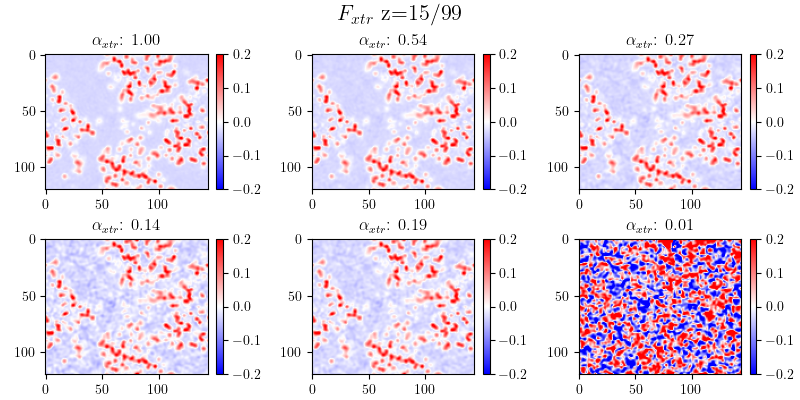

interactive(children=(IntSlider(value=15, description='f0', max=99), Output()), _dom_classes=('widget-interact…

In [21]:
# visualizing the extrapolated structures
%matplotlib widget
alpha_xtrs_vis = np.array([1, alpha * 2, alpha, alpha / 2, 0.19, 0.01])
f_xtrs_vis = make_f_xtr(
    alpha_xtrs_vis, f_dark, f_light, np.angle(f_dark), version=1, noise_level=0
)
dens_xtrs_vis = np.array([np.fft.ifftn(f_xtr).real for f_xtr in f_xtrs_vis])
print(dens_xtrs_vis.ndim)
if dens_xtrs_vis.ndim==4:
    anim = show_xtrs( dens_xtrs_vis, alpha_xtrs_vis, obj0, alpha, version="only", variant=imagetype, make_gif=False, )
elif dens_xtrs_vis.ndim==3:
    fig, axs = plt.subplots(2,3, figsize=(8,4),constrained_layout=True)
    steps = 1

    for ax, alpha_xtr, arr in zip(axs.flat, alpha_xtrs_vis,dens_xtrs_vis):

        raw = [r"$\alpha_{xtr}$",
               r"$\alpha_t$"]
        tit = f"{raw[0]}: {alpha_xtr:.2f}"
        ax.set_title(tit)
        diff = arr/np.max(arr)-obj0/np.max(obj0)
        vmax = np.max(diff)
        im = ax.imshow(diff, cmap="bwr",vmin=-vmax, vmax=vmax)
        plt.colorbar(im)
    plt.suptitle(r"$\frac{F_{xtr}}{\max_q(F_{xtr})} - \frac{F_0}{\max_q(F_0)}$")
    plt.show()    
        

interactive(children=(IntSlider(value=0, description='f0', max=99), Output()), _dom_classes=('widget-interact'…

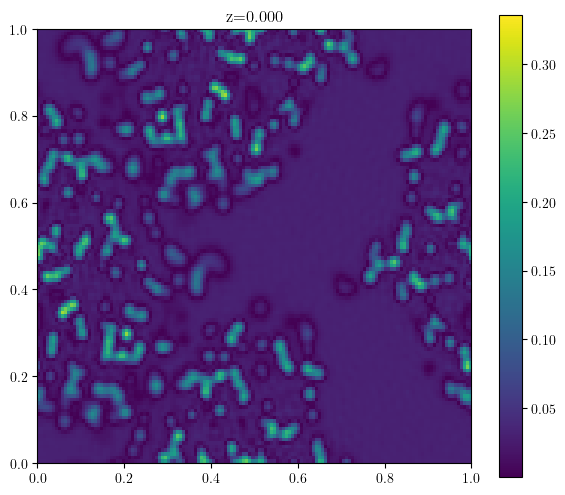

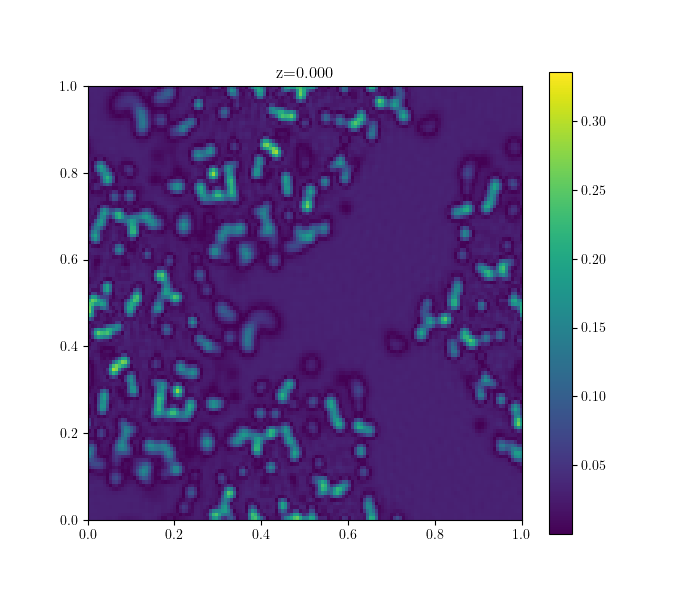

In [22]:
slice_3d(np.abs(np.fft.ifftn(f_dark)))

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19.]
intersection point, 10.679 (0.19)
using the following for plot name:ct_occ_27_noise_0
saving in /Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/plots/ct_occ_27_noise_0_negsumexplosion.png
saving in /Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/../tex/figs/ct_occ_27_noise_0_negsumexplosion.pdf


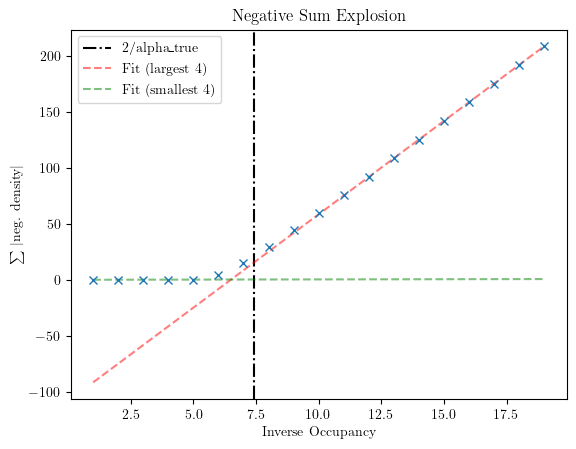

In [48]:
title = "Negative Sum Explosion"

alpha_invs = np.concatenate([
    np.arange(1, 8,0.8),
    np.arange(9, 50,5),
])
alpha_invs = (np.arange(1,20)+1e-10)
print(alpha_invs)
alpha_xtrs_other = 2/alpha_invs
# alpha_xtrs_other = np.sort(np.concatenate([alpha_xtrs, alpha_xtrs_other]))[::-1]
# alpha_invs_other = 2/alpha_xtrs_other
alpha_invs_other = alpha_invs
delta_obj = obj1-obj0
mask_pks_neg = (delta_obj)<-mask_thresh
f_xtrs_other = make_f_xtr(alpha_xtrs_other, f_dark, f_light, np.angle(f_dark),  version=1, noise_level = 0)
_, neg_sum = marius(f_xtrs_other, mask_pks_neg)
n_largest = 7
n_more = 4

from compare_conds import get_intersect_and_angle
isect = get_intersect_and_angle(alpha_xtrs_other, neg_sum, 3)[0]

neg_sum_explosion(alpha_invs_other, neg_sum, config, None, n_more, title=title)
# plt.xlim(0,7)
# plt.ylim(-50,400)

interactive(children=(IntSlider(value=0, description='f0', max=99), Output()), _dom_classes=('widget-interact'…


KeyboardInterrupt

Exception ignored in: Traceback (most recent call last):
'zmq.backend.cython._zmq.Frame.__dealloc__'
Traceback (most recent call last):
  File "_zmq.py", line 169, in zmq.backend.cython._zmq._check_rc
  File "_zmq.py", line 169, in zmq.backend.cython._zmq._check_rc
KeyboardInterrupt
KeyboardInterrupt: 


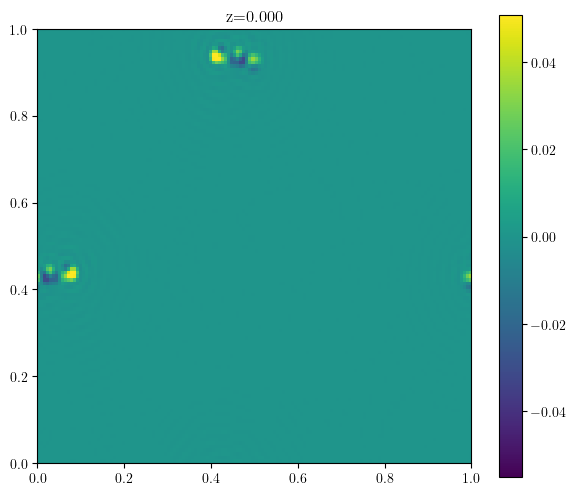

In [19]:
delta_obj = obj1-obj0
mask_pks = np.abs(delta_obj)>mask_thresh
# mask_pks = (delta_obj)<-0.05
if mask_pks.ndim == 2: plt.figure(); plt.imshow(mask_pks)
else: _ = slice_3d(delta_obj)

difference_map_plot(alpha_xtrs, f_xtrs, mask_pks, obj0, delta_obj, config, save_output=True)

In [ ]:
slice_3d(delta_obj)

share of active pixel: 0.153%
share of active pixel: 0.019%


/var/folders/pr/w1s1g8813qn100g39nl2z99m0000gp/T/ipykernel_19103/3464744806.py:10: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig,axs=plt.subplots(1,3)


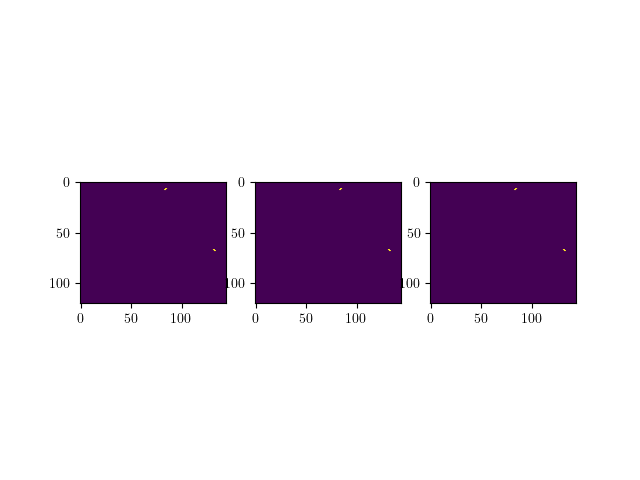

using the following for plot name:ct_occ_27_noise_0
saving in /Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/plots/ct_occ_27_noise_0_pandda_bins.png
saving in /Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/../tex/figs/ct_occ_27_noise_0_pandda_bins.pdf
using the following for plot name:ct_occ_27_noise_0
saving in /Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/plots/ct_occ_27_noise_0_pandda.png
saving in /Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/../tex/figs/ct_occ_27_noise_0_pandda.pdf


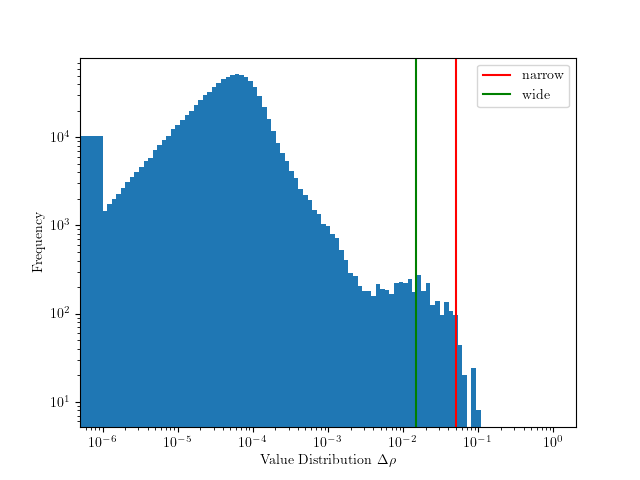

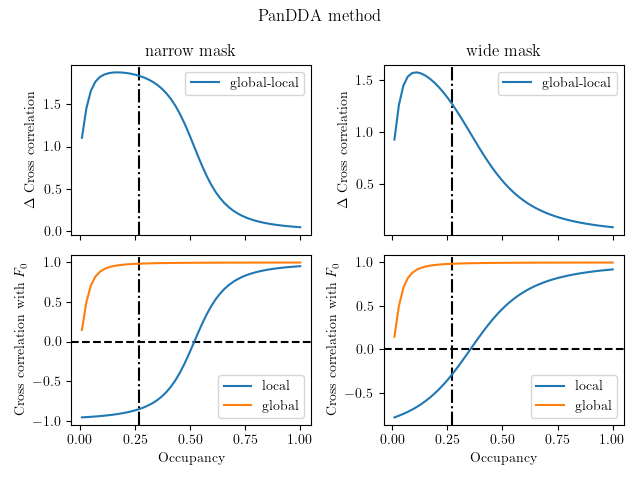

In [35]:
# mask_pks = gaussian_filter(np.abs(delta_obj),1)>0.01
mask_pks_lax = (np.abs(delta_obj))>lax
mask_pks_strict = gaussian_filter(np.abs(delta_obj),1)>strict
mask_pks_lax = gaussian_filter(np.abs(delta_obj),1)>lax
mask_pks_strict = (np.abs(delta_obj))>strict
mask_pks_general = (np.abs(delta_obj))>mask_thresh
for mask in [mask_pks_lax, mask_pks_strict]:
    print(f"share of active pixel: {np.sum(mask)/mask.size:.3%}")
    
fig,axs=plt.subplots(1,3)
for ax, mask in zip(axs,[mask_pks_strict,mask_pks_general,mask_pks_lax]):
    slc = slice() if mask.ndim ==2 else 0
    ax.imshow(mask_pks_strict[slc])
plt.show()

pandda_bin_comp(delta_obj, strict, lax, config)

pandda_plot(alpha_xtrs, f_xtrs, f_dark, mask_pks_lax, mask_pks_strict, config)


In [36]:
from plotting3d import density_matching
save_plot = True
mask_pks_neg = delta_obj<-strict
density_matching(f_xtrs, alpha_xtrs, mask_pks_neg, config)

KeyboardInterrupt: 

# Rename files after the fact

In [ ]:
for ns in ["no",""]:
    for tp in ["blobs"]:
        pass
        name = f"../tex/figs/cistrans_{ns}noise_offset_density_matching_{tp}"
        end = '.pdf'
        name_in = name+end
        name_out = name+"_lthresh"+end
        #!mv $name_in $name_out
        !echo "mv $name_in $name_out"

mv ../tex/figs/cistrans_nonoise_offset_density_matching_blobs.pdf ../tex/figs/cistrans_nonoise_offset_density_matching_blobs_lthresh.pdf
mv ../tex/figs/cistrans_noise_offset_density_matching_blobs.pdf ../tex/figs/cistrans_noise_offset_density_matching_blobs_lthresh.pdf


# Histograms

In [12]:
from scipy.signal import correlate
from scipy.stats import wasserstein_distance

true_xtr = (obj1-obj0*(1-alpha))/alpha
# true_xtr = obj1_truth
def correl(im1, im2):
    slc = [0,]*im1.ndim
    return (correlate(im1,im2, mode="valid")/np.sqrt( 
    correlate(im1,im1, mode="valid")*
    correlate(im2,im2, mode="valid")))[*slc]

def val_distributions(density_dark, density_light, mask, config,axs = None ):
    max_density = max(np.max(density_dark), np.max(density_light))
    log_max = np.log(max_density) 
    print(log_max)
    bins = np.logspace(-5, log_max, 100)
    bins = np.sort(np.concatenate([bins,-bins]))
    bins = np.linspace(-0.1,0.4,config["number_bins"])
    bins = np.arange(-0.5,1,0.005)
    bins = np.arange(-1,1.4,0.005)
    print(bins[1]-bins[0])

    # Plot histograms on first subplot
    occu_txt = f"Occupancy Estimate (True):\n {config['alpha_xtr']}({config['alpha']})"
    occu_txt2 = f"Occupancy:\n {config['alpha_xtr']}({config['alpha']})"
    if axs is None:
        fig, axs = plt.subplots(1,2,tight_layout=True)
        fig.suptitle(occu_txt)
    else:
        print(axs)
        axs[0].set_ylabel(occu_txt2)
    ax = axs[0]
    hist_dark, _, _ = ax.hist(density_dark[mask].ravel(), bins=bins, alpha=0.5, label='Dark')
    hist_light, _, _ = ax.hist(density_light[mask].ravel(), bins=bins, alpha=0.5, label='Extrapol.')
    if (hist_light==0).all():
        hist_light[0]=1
    # ax.set_xscale('symlog',linthresh=1e-3)
    wd = wasserstein_distance(bins[:-1],bins[:-1],hist_dark, hist_light)
    cc_ROC = correl(density_light[mask], true_xtr[mask])
    cc_glob = correl(density_light, true_xtr)
    title = f"Wasserstein Distance: {wd:.4f}"#, W-mult: {wd*len(bins)"
    title += f"\nCC: {cc_glob:.4f}"
    title += f"\tCC (RoC): {cc_ROC:.4f}"
    ax.set_title(title)
    ax.set_xlabel("Density")
    ax.legend()
    if config["zoom_in"]:
        ax.set_ylim(0,np.max(hist_dark))
        # ax.set_ylim(0,50_000)
    # ax.set_xlim(0,50_000)
    print("hist_dark max",np.max(hist_dark))

    # Plot difference on second subplot
    ax = axs[1]
    bin_centers = bins[:-1] + np.diff(bins)
    diff = hist_light - hist_dark
    bin_widths = bins[1:] - bins[:-1]
    diff = hist_light - hist_dark

    ax.bar(bin_centers, diff, width=bin_widths, align='center', label = "Extrapol. - Dark)")
    # ax.set_xscale('log')

    # ax.plot(bin_centers, diff, drawstyle='steps-mid')
    # ax.set_title()
    ax.axhline(0, color='gray', linestyle='--')
    ax.legend()
    ax.set_xlabel("Density")
    ax.set_ylabel("Count Difference")
    # ax.set_xscale('symlog',linthresh=1e-3)
    if config["zoom_in"]:
        ax.set_ylim(-500,500)
        ax.set_ylim(-50,50)
# val_distributions(density_dark, density_light) 

In [8]:
%matplotlib inline


In [9]:
wasserstein_distance(
    np.arange(5),
    np.arange(5),
    [0,0,0,1,1],
    [1,1,0,0,0],
)

3.0

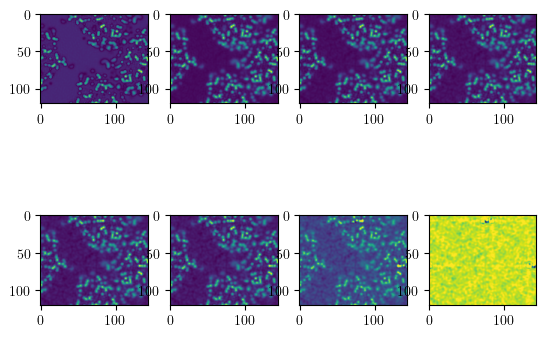

In [13]:
fig, axs = plt.subplots(2,4)
ax =  axs[0,0]
dens0 = np.abs(np.fft.ifftn(f_dark)[0])
# print(dens0.size)
ax.imshow(dens0)
for idx,dens in enumerate(dens_xtrs_vis):
    # print(dens.size)
    ax =  axs.flat[idx+1]
    ax.imshow(dens[0], vmax= np.max(dens0))

interactive(children=(IntSlider(value=0, description='f0', max=99), Output()), _dom_classes=('widget-interact'…

-0.6708206695457535
0.0050000000000000044
hist_dark max 88.0
-0.6708206695457535
0.0050000000000000044
hist_dark max 88.0
-0.6708206695457535
0.0050000000000000044
hist_dark max 88.0
-0.6708206695457535
0.0050000000000000044
hist_dark max 88.0
-0.6708206695457535
0.0050000000000000044
hist_dark max 88.0
-0.2266951042235429
0.0050000000000000044
hist_dark max 88.0
2.3751252658546975
0.0050000000000000044
hist_dark max 88.0


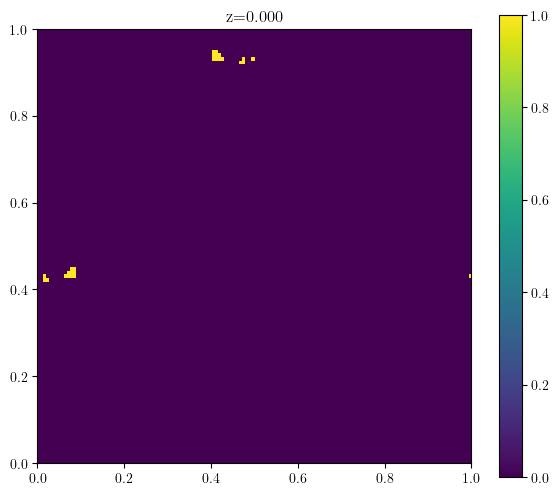

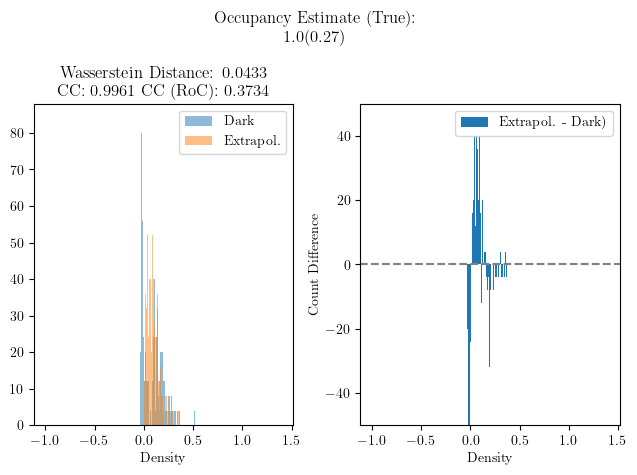

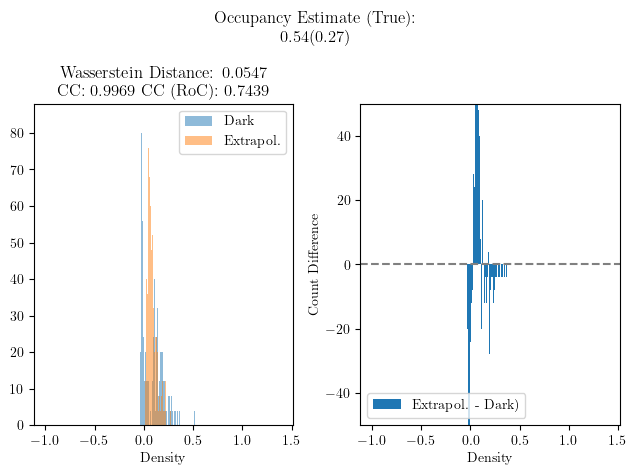

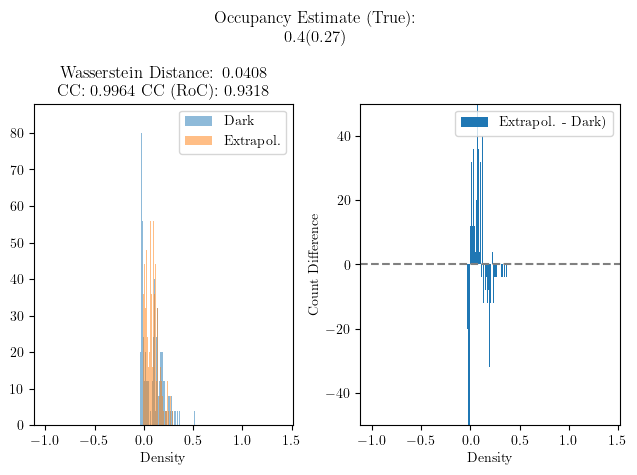

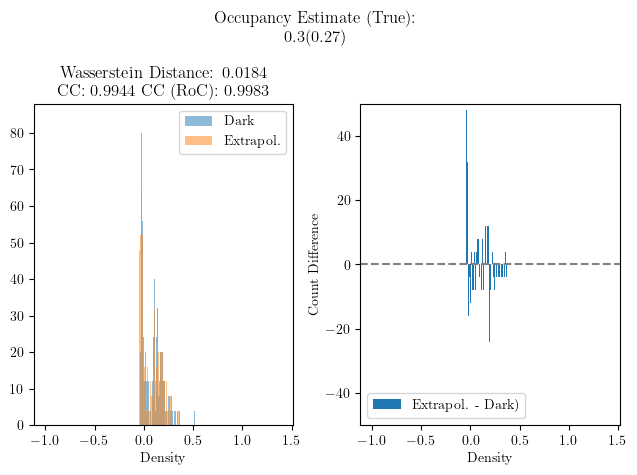

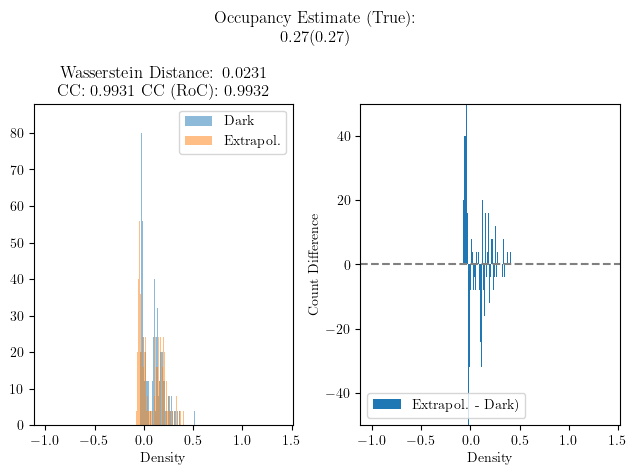

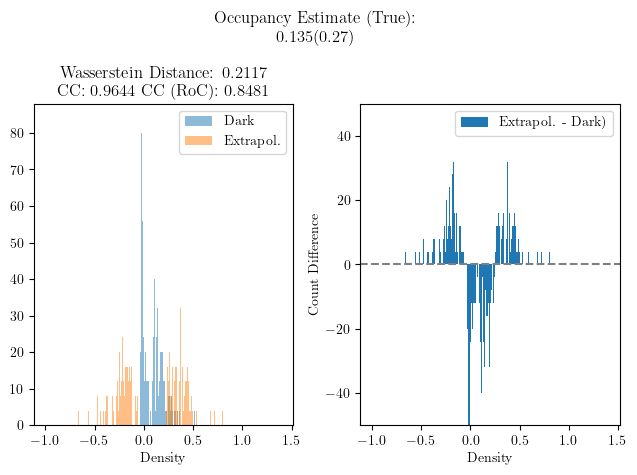

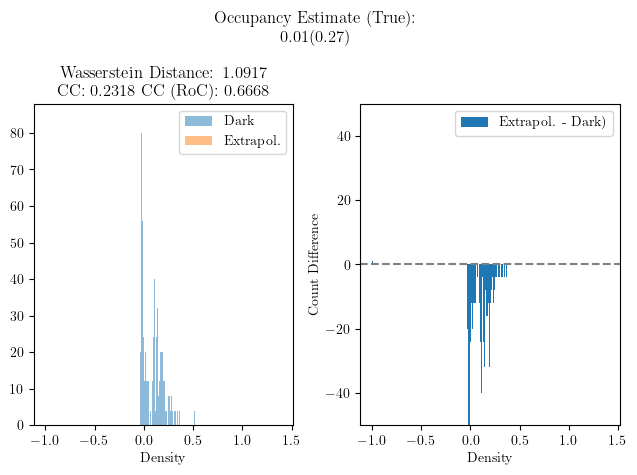

In [18]:
dens_dark = (np.fft.ifftn(f_dark)).real
# print(np.max(dens_xtrs_vis))
from scipy.stats import wasserstein_distance
# %matplotlib widget
alpha_xtrs_vis = np.array([1, alpha * 2,0.4, 0.3,alpha, alpha / 2,  0.01])
f_xtrs_vis = make_f_xtr(
    alpha_xtrs_vis, f_dark, f_light, np.angle(f_dark), version=1, noise_level=0
)
dens_xtrs_vis = np.array([np.fft.ifftn(f_xtr).real for f_xtr in f_xtrs_vis])
%matplotlib inline

config = {
    "alpha": alpha,
    "number_bins": 50,
    "zoom_in": True
}
# fig, axso = plt.subplots(3,2)
# for jj, thresh in enumerate([mask_thresh, -np.inf]):
# mask_pks_general = (np.abs(delta_obj))>thresh
mask_pks_general = (np.abs(delta_obj))>-np.inf
mask_pks_general = gaussian_filter(np.abs(delta_obj),3)>mask_thresh/15
mask_pks_general = (np.abs(delta_obj))>mask_thresh
slice_3d(mask_pks_general)
    

# print(np.min(obj1))
for axs_idx, ii in enumerate(range(len(alpha_xtrs_vis))):
        # axs_in = axso[axs_idx,:]
        dens = dens_xtrs_vis[ii]
        config["alpha_xtr"]= alpha_xtrs_vis[ii]
        # print(alpha_xtrs_vis[ii])
        val_distributions(dens_dark, dens,mask_pks_general, config)
        plt.tight_layout()
    

interactive(children=(IntSlider(value=0, description='f0', max=99), Output()), _dom_classes=('widget-interact'…

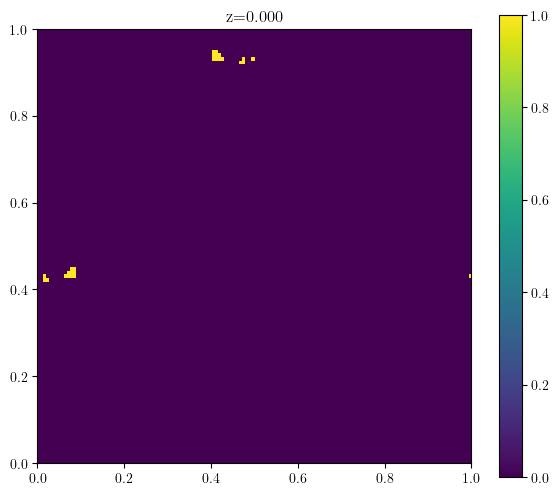

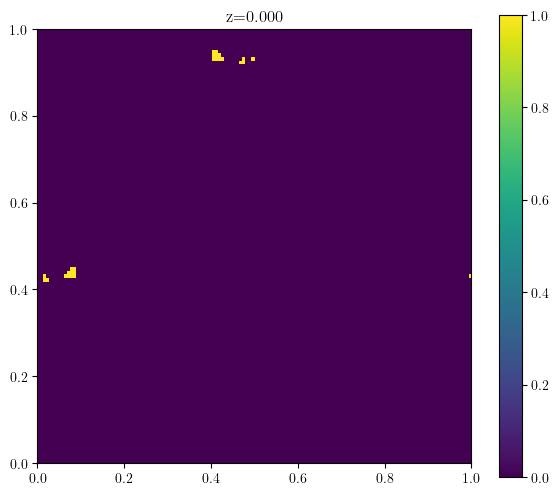

In [16]:
mask_pks_general = gaussian_filter(np.abs(delta_obj),1)>mask_thresh/10
mask_pks_general = np.abs(delta_obj)>mask_thresh
slice_3d(mask_pks_general)


-0.6708206695457533
0.0050000000000000044
hist_dark max 88.0


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

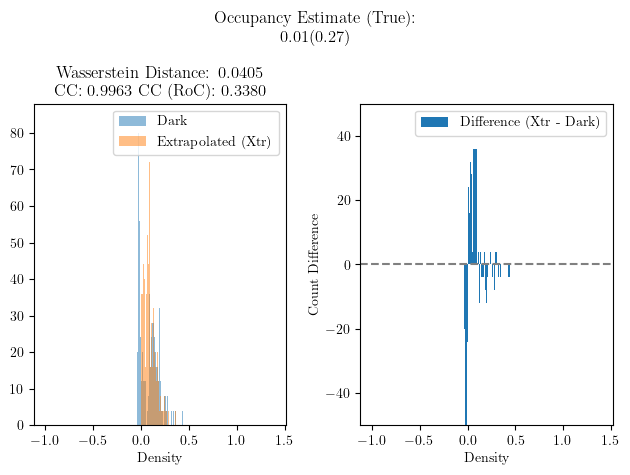

In [203]:
val_distributions(obj0, obj1,mask_pks_general, config)
plt.tight_layout

-0.8189169572272447
0.0050000000000000044
hist_dark max 136.0


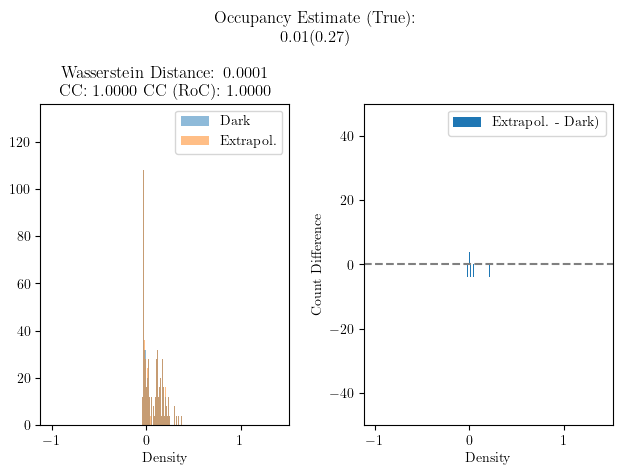

In [216]:
val_distributions(obj1_truth, true_xtr,mask_pks_general, config)


In [220]:
%matplotlib inline
plt.figure()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

10.752360005285441
-0.6708206695457535
0.0050000000000000044
[<Axes: > <Axes: >]
hist_dark max 88.0
-0.6708206695457535
0.0050000000000000044
[<Axes: > <Axes: >]
hist_dark max 88.0
-0.6708206695457535
0.0050000000000000044
[<Axes: > <Axes: >]
hist_dark max 88.0
-0.2266951042235429
0.0050000000000000044
[<Axes: > <Axes: >]
hist_dark max 88.0


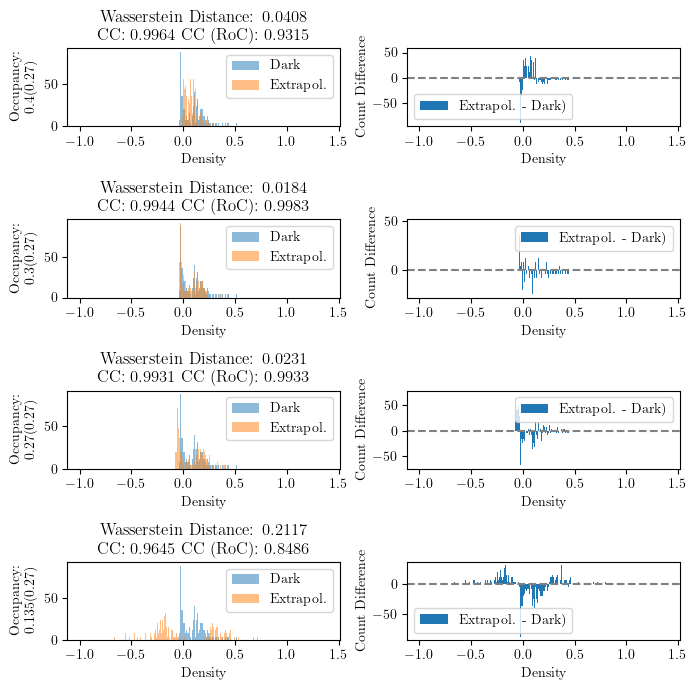

In [221]:
dens_dark = (np.fft.ifftn(f_dark)).real
print(np.max(dens_xtrs_vis))



config = {
    "alpha": alpha,
    "number_bins": 100,
    "zoom_in": False
}
fig, axso = plt.subplots(4,2, figsize=(7,7))
# for jj, thresh in enumerate([mask_thresh, -np.inf]):
# mask_pks_general = (np.abs(delta_obj))>thresh
mask_pks_general = (np.abs(delta_obj))>mask_thresh
    

for axs_idx, ii in enumerate((2,3,4,5)):
        axs_in = axso[axs_idx,:]
        dens = dens_xtrs_vis[ii]
        config["alpha_xtr"]= alpha_xtrs_vis[ii]
        val_distributions(dens_dark, dens,mask_pks_general, config, axs_in)
        
plt.tight_layout()
    


interactive(children=(IntSlider(value=0, description='f0', max=99), Output()), _dom_classes=('widget-interact'…

interactive(children=(IntSlider(value=0, description='f0', max=99), Output()), _dom_classes=('widget-interact'…

TypeError: val_distributions() missing 1 required positional argument: 'config'

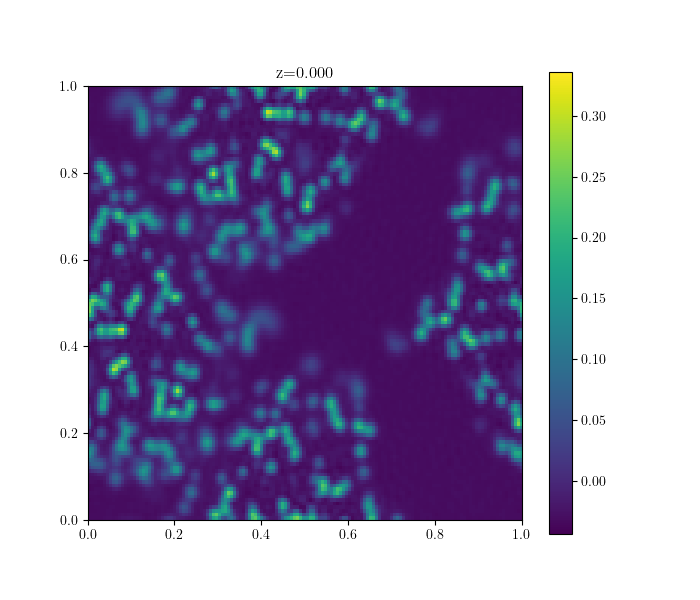

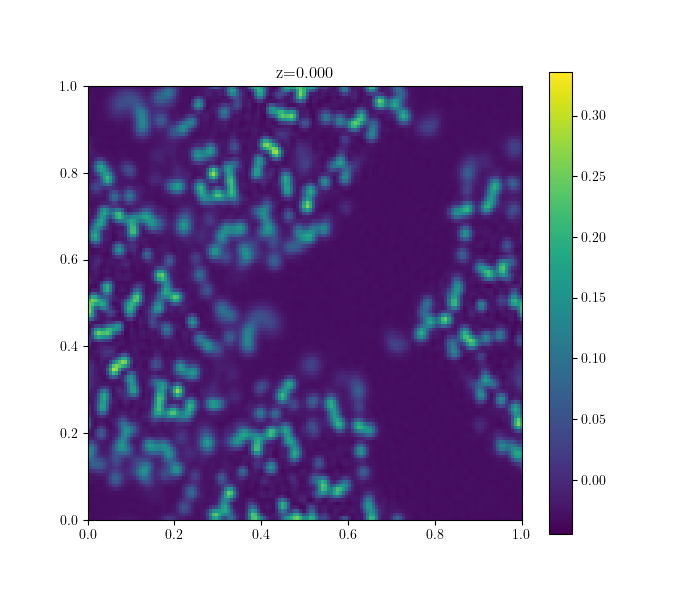

In [222]:

%matplotlib widget
slice_3d(true_xtr)
slice_3d(obj0)
val_distributions(obj0[mask_pks_general], true_xtr[mask_pks_general], config)

(correl(obj0,obj1),
correl(obj0,true_xtr),
correl(obj0[mask_pks_general],obj1[mask_pks_general]),
correl(obj0[mask_pks_general],true_xtr[mask_pks_general]),
)
# 

# plt.tight_layout()

[0, 0, 0]

In [112]:
alpha

0.27

10.752360005285441
1.0
-0.6708206695457535
0.0050000000000000044
[<Axes: > <Axes: >]
hist_dark max 88.0
0.4
-0.6708206695457535
0.0050000000000000044
[<Axes: > <Axes: >]
hist_dark max 88.0
0.3
-0.6708206695457535
0.0050000000000000044
[<Axes: > <Axes: >]
hist_dark max 88.0


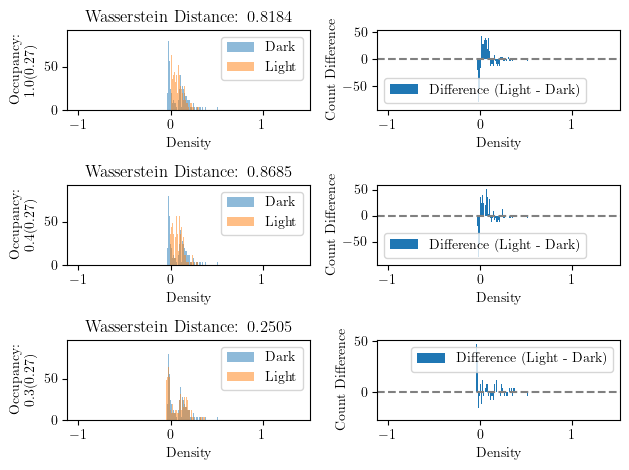

In [82]:
dens_dark = (np.fft.ifftn(f_dark)).real
print(np.max(dens_xtrs_vis))

alpha_xtrs_vis = np.array([1, alpha * 2,0.4, 0.3,alpha, alpha / 2,  0.01])
f_xtrs_vis = make_f_xtr(
    alpha_xtrs_vis, f_dark, f_light, np.angle(f_dark), version=1, noise_level=0
)
dens_xtrs_vis = np.array([np.fft.ifftn(f_xtr).real for f_xtr in f_xtrs_vis])


config = {
    "alpha": alpha,
    "number_bins": 100,
    "zoom_in": False
}
fig, axso = plt.subplots(3,2)
# for jj, thresh in enumerate([mask_thresh, -np.inf]):
# mask_pks_general = (np.abs(delta_obj))>thresh
mask_pks_general = (np.abs(delta_obj))>mask_thresh
    

for axs_idx, ii in enumerate((0,2,3)):
        axs_in = axso[axs_idx,:]
        dens = dens_xtrs_vis[ii]
        config["alpha_xtr"]= alpha_xtrs_vis[ii]
        print(alpha_xtrs_vis[ii])
        val_distributions(dens_dark[mask_pks_general], dens[mask_pks_general], config, axs_in)
plt.tight_layout()


In [ ]:

def make_mtz_for_scaleit(f_obs_ref, f_obs_2):
    mtz_out  = "forscaleit.mtz"
    f_obs_ms = f_obs_ref.as_mtz_dataset(column_root_label="F_obs_ref")
    f_obs_ms.add_miller_array(f_obs_2,  column_root_label="F_obs_2")
    f_obs_ms.mtz_object().write(file_name = mtz_out)
    return mtz_out

def write_scaleit_input(mtz_in, b_scaling, low_res, high_res):
    mtz_out    = "fromscaleit.mtz"
    script_out = 'launch_scaleit.sh'
    i = open(script_out,'w')
    i.write("#!/bin/bash\n\
scaleit HKLIN %s HKLOUT %s <<eof > scaleit.log\n\
REFINE %s \n\
RESOLUTION %.2f %.2f \n\
LABIN FP = F_obs_ref SIGFP = SIGF_obs_ref  FPH1 = F_obs_2 SIGFPH1 = SIGF_obs_2 \n\
eof" %(mtz_in, mtz_out, b_scaling, low_res, high_res))
    i.close()
    return mtz_out, script_out

def run_scaleit(f_obs_ref, f_obs_2, b_scaling, low_res=None, high_res=None, log=sys.stdout):
    if b_scaling   == 'isotropic':
        b_scaling  = 'ISOTROPIC'
    elif b_scaling == 'anisotropic':
        b_scaling  = 'ANISOTROPIC'
    else:
        b_scaling  = 'SCALE'
        
    dmax, dmin = f_obs_2.d_max_min()
    if low_res == None:
        low_res = dmax
    if high_res == None:
        high_res = dmin
        
    mtz_forscaleit = make_mtz_for_scaleit(f_obs_ref, f_obs_2)
    mtz_fromscaleit, script_scaleit = write_scaleit_input(mtz_forscaleit, b_scaling, low_res, high_res)
    os.system("chmod +x %s" %(script_scaleit))
    print("Running scaleit, see %s" %(script_scaleit), file=log)
    os.system("./%s" %(script_scaleit))

    reflections = any_file(mtz_fromscaleit, force_type="hkl", raise_sorry_if_errors=True)
    refl        = reflections.file_object.as_miller_arrays()
    f_obs_2 = [st for i,st in enumerate(refl) if "F_obs_2" in str(refl[i].info())][0]
    
    return f_obs_2
